<a href="https://colab.research.google.com/github/weenachuangkud/neural-numbers-py/blob/main/Neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import io

print("Libraries loaded")

In [9]:
# Load dataset of handwritten digits (0-9)
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

print(f"Loaded {len(train_images)} training images")
print(f"Each image is {train_images[0].shape} pixels")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Loaded 60000 training images
Each image is (28, 28) pixels


In [11]:
# Create a simple neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model created!")
model.summary()

Model created!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train it (this takes ~1 minute)
print("Training started...")
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_split=0.2,
    verbose=1
)

print("Training complete!")

🚀 Training started...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9702 - loss: 0.0975 - val_accuracy: 0.9725 - val_loss: 0.0904
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9747 - loss: 0.0812 - val_accuracy: 0.9753 - val_loss: 0.0840
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9776 - loss: 0.0698 - val_accuracy: 0.9764 - val_loss: 0.0806
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9792 - loss: 0.0632 - val_accuracy: 0.9768 - val_loss: 0.0834
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9813 - loss: 0.0569 - val_accuracy: 0.9762 - val_loss: 0.0831
Training complete!


In [14]:
# See how good it is
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\n Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0790

 Accuracy: 97.66%


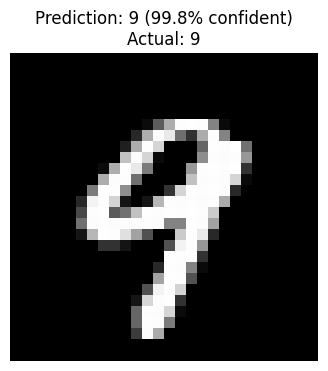

In [15]:
# Let's test it on some examples
def predict_digit(image_array):
    # Reshape for model
    img = image_array.reshape(1, 28, 28)
    img = img / 255.0

    # Predict
    prediction = model.predict(img, verbose=0)
    digit = np.argmax(prediction)
    confidence = prediction[0][digit] * 100

    return digit, confidence

# Test on a random digit from dataset
idx = np.random.randint(0, len(test_images))
test_img = test_images[idx]
digit, conf = predict_digit(test_img * 255)

plt.figure(figsize=(4, 4))
plt.imshow(test_img, cmap='gray')
plt.title(f"Prediction: {digit} ({conf:.1f}% confident)\nActual: {test_labels[idx]}")
plt.axis('off')
plt.show()